In [252]:
import json
with open(r"C:\Users\flori\OneDrive\Studium\AI Bachelor\Courses\5.Semester\CS 325 - Software Engineering\Project\Part2\reviews.json", 'r') as file:
        data = json.load(file) 

In [ ]:
import ollama
from httpx import ConnectError
from tqdm import tqdm


class OllamaLLM():
    def __init__(self, host_address:str=None, model_name:str="phi3:3.8b") -> None:
        assert isinstance(host_address, str)
        assert isinstance(model_name, str)

        self.host = host_address
        self.model = model_name

        self.client = ollama.Client(host=self.host)
        
        self._check_model()


        
    def _check_model(self):
        try:
            model_data = self.client.show(self.model)
        except ConnectError as e:
            raise ConnectionError(f"Could not connect to Ollama host: {e}")
        except ollama.ResponseError as e:
            print(e)
            if e.status_code == 404:
                user_input = input(f"Do you want to download {self.model} from the repository? (Y/n)").lower()
                if user_input == "yes" or user_input == "y":
                    self.download_model(self.model, verbose=True)


    def download_model(self, model_name, verbose=False):
        assert isinstance(model_name, str)
        assert isinstance(verbose, bool)

        if verbose:
            current_digest, bars = '', {}
            for progress in self.client.pull(self.model, stream=True):
                digest = progress.get('digest', '')
                if digest != current_digest and current_digest in bars:
                    bars[current_digest].close()
                if not digest:
                    print(progress.get('status'))
                    continue
                if digest not in bars and (total := progress.get('total')):
                    bars[digest] = tqdm(total=total, desc=f'pulling {digest[7:19]}', unit='B', unit_scale=True)
                if completed := progress.get('completed'):
                    bars[digest].update(completed - bars[digest].n)
                current_digest = digest
        else:
            self.client.pull(model_name)

    def do_sentiment_analysis(self, reviews:list, prompt_template:str, verbose=True):
        assert isinstance(reviews, list)
        assert isinstance(prompt_template, str)

        sentiments = []
        # reviews = reviews[:25]

        for review in tqdm(reviews, disable=not verbose, desc="progress:"):
            result = self.client.generate(
                model=self.model,
                prompt=prompt_template.format(review=review)
            )
            sentiments.append(result)

        return sentiments


In [267]:
llm = OllamaLLM(
    host_address="http://192.168.100.8:11434",
    model_name="llama3.2:1b"#'phi3:3.8b'
    )

import json
from utils import batch_reviews

# prompt_template = "input: {review}\nClassify the sentiment of the message:"
# prompt_examples = [
#     "input: I had to compare two versions of Hamlet for my Shakespeare class and unfortunately I picked this version…\nClassify the sentiment of the message: negative",
#     "input: This Charles outing is decent but I have seen better.\nClassify the sentiment of the message: neutral",
#     "input: My family has watched Arthur Bach stumble and stammer since the movie first came out. We have most lines memorized…\nClassify the sentiment of the message: positive"
# ]
prompt_template = 'Analyze the sentiment of the following product review and respond with *only* the word "positive," "neutral," or "negative" based on the overall tone. Do not include any additional text.\n\n{review}'

In [268]:
res = llm.do_sentiment_analysis(data[0]["reviews"], prompt_template, verbose=True)
len(res)

progress:: 100%|██████████| 25/25 [00:27<00:00,  1.08s/it]


25

In [269]:
for r in res:
    print("-"*50)
    print(r["response"])

--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
Negative
--------------------------------------------------
positive
--------------------------------------------------
neutral
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
negative
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
--------------------------------------------------
positive
-----------------------------------------

In [256]:
i = 1
print("Prompt Statistics:")
print(f'Model: {res[i]["model"]}')
print(f'done: {res[i]["done"]}')
print(f'total_duration: {res[i]["total_duration"]/1e9} s')
print(f'load_duration: {res[i]["load_duration"]/1e9} s')
print(f'prompt_eval_count: {res[i]["prompt_eval_count"]}')
print(f'prompt_eval_duration: {res[i]["prompt_eval_duration"]/1e9} s')
print(f'eval_count: {res[i]["eval_count"]}')
print(f'eval_duration: {res[i]["eval_duration"]/1e9} s')
print(f'Response: {res[i]["response"]}')


Prompt Statistics:
Model: llama3.2:1b
done: True
total_duration: 2.295073165 s
load_duration: 0.010782501 s
prompt_eval_count: 215
prompt_eval_duration: 2.212314 s
eval_count: 2
eval_duration: 0.029604 s
Response: positive


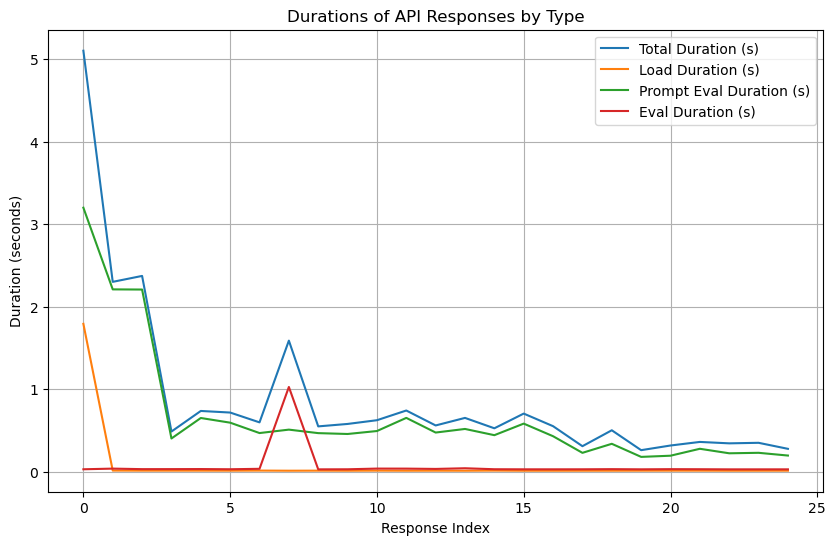

In [271]:
import matplotlib.pyplot as plt

# Extract data for the plot
total_duration = [item["total_duration"] / 1e9 for item in res]
load_duration = [item["load_duration"] / 1e9 for item in res]
prompt_eval_duration = [item["prompt_eval_duration"] / 1e9 for item in res]
eval_duration = [item["eval_duration"] / 1e9 for item in res]

# Create x-axis based on the index of each response
indices = list(range(len(res)))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(indices, total_duration, label='Total Duration (s)')
plt.plot(indices, load_duration, label='Load Duration (s)')
plt.plot(indices, prompt_eval_duration, label='Prompt Eval Duration (s)')
plt.plot(indices, eval_duration, label='Eval Duration (s)')

# Labeling and title
plt.xlabel('Response Index')
plt.ylabel('Duration (seconds)')
plt.title('Durations of API Responses by Type')
plt.legend()
plt.grid(True)
plt.show()

